In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400
2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800
2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200
2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800
2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800
...,...,...,...,...,...
2026-05-15,300.230011,303.200012,296.519989,297.899994,54862800
2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000


# 2. Data Exploration & Visualization

In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400
2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800
2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200
2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800
2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800
...,...,...,...,...,...
2026-05-15,300.230011,303.200012,296.519989,297.899994,54862800
2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000


In [4]:
type(df)

pandas.DataFrame

In [5]:
df.shape

(2514, 5)

In [6]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,123.469662,124.695222,122.120972,123.351338,9.665941e+07
std,76.475528,77.204440,75.668575,76.397629,5.483332e+07
min,20.952871,21.182798,20.829940,21.148654,1.791060e+07
25%,44.871827,45.209901,44.454970,44.789954,5.735085e+07
50%,128.972771,130.646915,127.633182,129.007369,8.489835e+07
75%,179.722294,181.136957,178.043732,179.576435,1.176314e+08
max,304.989990,305.540009,300.399994,301.059998,4.479400e+08


In [8]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [9]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400
2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800
2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200
2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800
2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800


In [10]:
df = df.reset_index()

In [11]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400
1,2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800
2,2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200
3,2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800
4,2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800


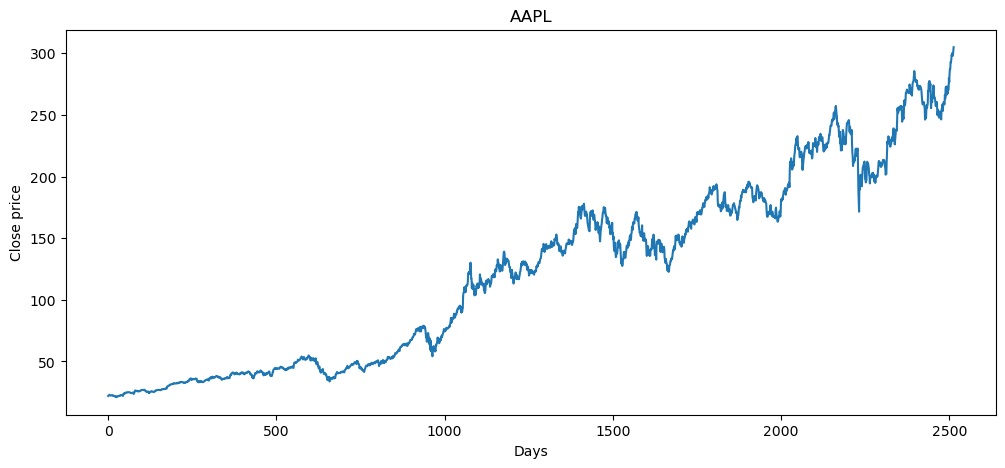

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price');

# 3. Feature Engineering

In [13]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA of 5 days ==> null null null null 30 40 

In [14]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[1:6])/5)

40.0


In [15]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [16]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 Days Moving Average

In [17]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400,NaN
1,2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800,NaN
2,2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200,NaN
3,2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800,NaN
4,2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800,NaN


In [18]:
df.head(103)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400,NaN
1,2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800,NaN
2,2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200,NaN
3,2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800,NaN
4,2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800,NaN
...,...,...,...,...,...,...,...
98,2016-10-11,26.619078,27.166108,26.596188,26.939512,256164000,NaN
99,2016-10-12,26.857113,27.003600,26.722073,26.859402,150347200,23.769299
100,2016-10-13,26.774715,26.880001,26.486323,26.731227,140769600,23.817523


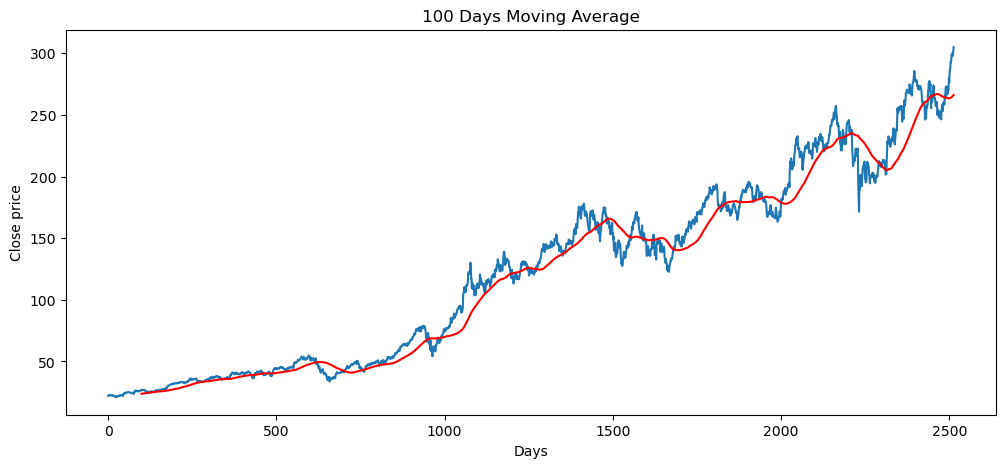

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close price');

# 200 Days Moving Average

In [20]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400,NaN,NaN
1,2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800,NaN,NaN
2,2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200,NaN,NaN
3,2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800,NaN,NaN
4,2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-03-07,32.236858,32.343142,32.068185,32.130571,69785200,27.551321,NaN
199,2017-03-08,32.116711,32.301556,32.075122,32.105157,74828800,27.603917,25.686608
200,2017-03-09,32.042786,32.068202,31.666167,32.056652,88623600,27.656597,25.737060


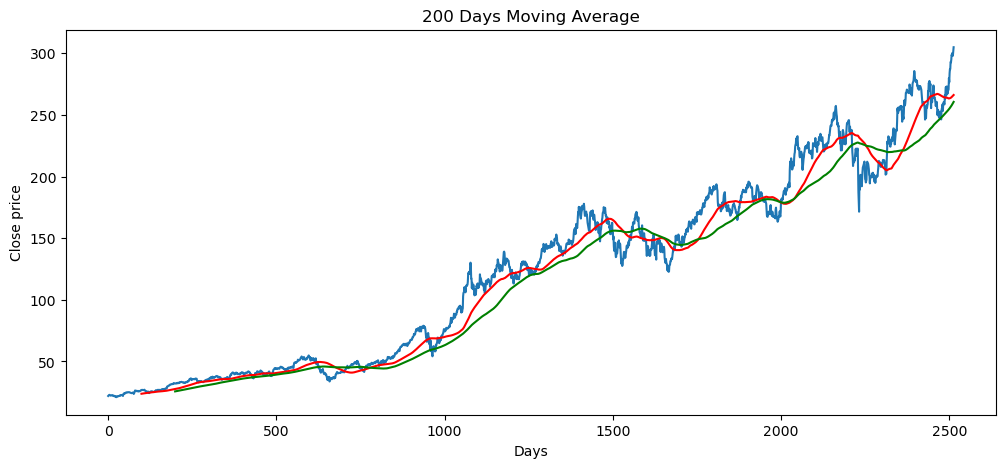

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Close price');

In [22]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-05-23,21.952255,22.125269,21.779241,21.824772,152074400,NaN,NaN
1,2016-05-24,22.286901,22.330154,22.045592,22.132100,140560800,NaN,NaN
2,2016-05-25,22.678452,22.705768,22.334700,22.462183,152675200,NaN,NaN
3,2016-05-26,22.858299,22.931147,22.455358,22.692114,225324800,NaN,NaN
4,2016-05-27,22.844643,22.871961,22.594228,22.637482,145364800,NaN,NaN
...,...,...,...,...,...,...,...,...
2509,2026-05-15,300.230011,303.200012,296.519989,297.899994,54862800,265.064240,258.651279
2510,2026-05-18,297.839996,300.660004,294.910004,300.239990,34483000,265.337965,259.106730
2511,2026-05-19,298.970001,300.510010,296.350006,296.970001,42243600,265.609116,259.593679


### Calculating % Changed in each trading sesssion

In [23]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,21.952255,NaN
1,22.286901,0.015244
2,22.678452,0.017569
3,22.858299,0.007930
4,22.844643,-0.000597
...,...,...
2509,300.230011,0.006774
2510,297.839996,-0.007961
2511,298.970001,0.003794


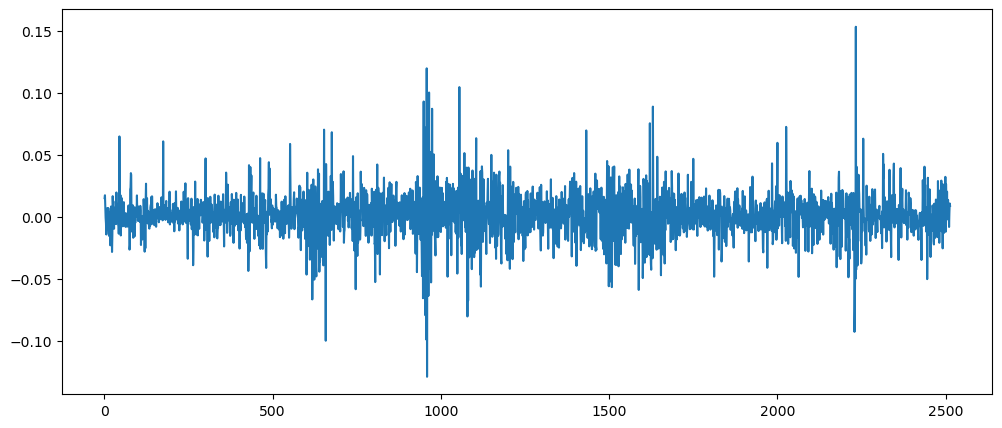

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

# 4. Data PreProcessing

In [25]:
df.shape

(2514, 9)

In [27]:
# Splitting data into Training & Testing Datasets

data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7): int(len(df))])

print(data_training)
print(data_testing)

Ticker        AAPL
0        21.952255
1        22.286901
2        22.678452
3        22.858299
4        22.844643
...            ...
1754    171.111160
1755    170.184189
1756    169.691086
1757    169.691086
1758    170.302505

[1759 rows x 1 columns]
Ticker        AAPL
1759    172.629868
1760    172.738388
1761    171.791595
1762    169.188110
1763    169.464249
...            ...
2509    300.230011
2510    297.839996
2511    298.970001
2512    302.250000
2513    304.989990

[755 rows x 1 columns]


In [28]:
data_training

Ticker,AAPL
0,21.952255
1,22.286901
2,22.678452
3,22.858299
4,22.844643
...,...
1754,171.111160
1755,170.184189
1756,169.691086
1757,169.691086


In [29]:
data_testing

Ticker,AAPL
1759,172.629868
1760,172.738388
1761,171.791595
1762,169.188110
1763,169.464249
...,...
2509,300.230011
2510,297.839996
2511,298.970001
2512,302.250000


In [30]:
# Scaling down the data between 0 and 1

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [32]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00636604],
       [0.00849772],
       [0.01099188],
       ...,
       [0.94745648],
       [0.94745648],
       [0.9513512 ]], shape=(1759, 1))

In [33]:
type(data_training_array)

numpy.ndarray

In [34]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [35]:
# 13, 12, 15, 10, 14, 16, 18, 19, 20, 21, 20      22

In [39]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [40]:
x_train

array([[[0.00636604],
        [0.00849772],
        [0.01099188],
        ...,
        [0.03572899],
        [0.03609351],
        [0.03760978]],

       [[0.00849772],
        [0.01099188],
        [0.0121375 ],
        ...,
        [0.03609351],
        [0.03760978],
        [0.03708491]],

       [[0.01099188],
        [0.0121375 ],
        [0.01205051],
        ...,
        [0.03760978],
        [0.03708491],
        [0.03803259]],

       ...,

       [[0.6956508 ],
        [0.69521225],
        [0.71494283],
        ...,
        [0.95531055],
        [0.9565023 ],
        [0.95059753]],

       [[0.69521225],
        [0.71494283],
        [0.69477369],
        ...,
        [0.9565023 ],
        [0.95059753],
        [0.94745648]],

       [[0.71494283],
        [0.69477369],
        [0.6924561 ],
        ...,
        [0.95059753],
        [0.94745648],
        [0.94745648]]], shape=(1659, 100, 1))

In [41]:
x_train.ndim

3

In [42]:
y_train.ndim

1

In [44]:
x_train.shape

(1659, 100, 1)

In [45]:
y_train.shape

(1659,)

In [46]:
x_train.ndim

3

# 6. Model Building

In [48]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [50]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [51]:
model = Sequential()

model.add(Input(shape = (100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [52]:
model.compile(optimizer ='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - loss: 0.0132
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 7.6961e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - loss: 7.2158e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - loss: 7.4964e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - loss: 7.6808e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 6.3727e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - loss: 5.9297e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - loss: 6.6578e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 6.6870e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 5.5552e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 5.8850e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 5.7832e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 5.5998e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 4.6305e-04
Epoch

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [54]:
# Save the trained model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [57]:
data_training.tail()

Ticker,AAPL
1754,171.111160
1755,170.184189
1756,169.691086
1757,169.691086
1758,170.302505


In [55]:
data_testing

Ticker,AAPL
1759,172.629868
1760,172.738388
1761,171.791595
1762,169.188110
1763,169.464249
...,...
2509,300.230011
2510,297.839996
2511,298.970001
2512,302.250000


In [58]:
past_100_days = data_training.tail(100)
past_100_days

Ticker,AAPL
1659,130.023209
1660,129.659378
1661,127.859932
1662,123.936523
1663,127.446945
...,...
1754,171.111160
1755,170.184189
1756,169.691086
1757,169.691086


In [60]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,130.023209
1,129.659378
2,127.859932
3,123.936523
4,127.446945
...,...
850,300.230011
851,297.839996
852,298.970001
853,302.250000


In [61]:
input_data = scaler.fit_transform(final_df)
input_data

array([[3.89421026e-02],
       [3.69436533e-02],
       [2.70596520e-02],
       [5.50914569e-03],
       [2.47911975e-02],
       [2.65196835e-02],
       [2.70047122e-04],
       [7.23758975e-03],
       [0.00000000e+00],
       [2.48452153e-02],
       [2.77079076e-02],
       [3.08406889e-02],
       [4.57478432e-02],
       [4.53156169e-02],
       [5.26070569e-02],
       [5.89804036e-02],
       [5.50375648e-02],
       [5.53615878e-02],
       [6.94043734e-02],
       [8.69041310e-02],
       [9.45739051e-02],
       [9.09551731e-02],
       [1.02297655e-01],
       [1.12937612e-01],
       [9.71123648e-02],
       [1.04079866e-01],
       [1.10237141e-01],
       [1.39349176e-01],
       [1.59225382e-01],
       [1.44264420e-01],
       [1.60035524e-01],
       [1.45290381e-01],
       [1.39619307e-01],
       [1.41620774e-01],
       [1.56983455e-01],
       [1.53467227e-01],
       [1.64989237e-01],
       [1.56226116e-01],
       [1.49951418e-01],
       [1.27935118e-01],


In [62]:
input_data.shape

(855, 1)

In [63]:
x_test=[]
y_test=[]
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i,0])

In [64]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [66]:
x_test[0].shape

(100, 1)

In [65]:
x_test

array([[[0.0389421 ],
        [0.03694365],
        [0.02705965],
        ...,
        [0.2568299 ],
        [0.2568299 ],
        [0.26018831]],

       [[0.03694365],
        [0.02705965],
        [0.00550915],
        ...,
        [0.2568299 ],
        [0.26018831],
        [0.27297205]],

       [[0.02705965],
        [0.00550915],
        [0.0247912 ],
        ...,
        [0.26018831],
        [0.27297205],
        [0.27356813]],

       ...,

       [[0.81799562],
        [0.82594533],
        [0.82369745],
        ...,
        [0.96275881],
        [0.97385438],
        [0.9607265 ]],

       [[0.82594533],
        [0.82369745],
        [0.82567142],
        ...,
        [0.97385438],
        [0.9607265 ],
        [0.96693339]],

       [[0.82369745],
        [0.82567142],
        [0.82194306],
        ...,
        [0.9607265 ],
        [0.96693339],
        [0.98494978]]], shape=(755, 100, 1))

# 9. Making Prediction

In [67]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [68]:
y_predicted

array([[0.2636465 ],
       [0.27246198],
       [0.27830932],
       [0.27754337],
       [0.26775008],
       [0.2625196 ],
       [0.26442352],
       [0.27430066],
       [0.28626207],
       [0.29189596],
       [0.30202994],
       [0.30952376],
       [0.30751878],
       [0.30347195],
       [0.29664338],
       [0.3020431 ],
       [0.30784035],
       [0.31993547],
       [0.32469887],
       [0.32759273],
       [0.33498785],
       [0.33493286],
       [0.33390188],
       [0.3296889 ],
       [0.33750913],
       [0.34160545],
       [0.33826172],
       [0.3450719 ],
       [0.35329136],
       [0.35802647],
       [0.37409535],
       [0.37671715],
       [0.37169036],
       [0.36985216],
       [0.36553198],
       [0.3566228 ],
       [0.35099715],
       [0.3553346 ],
       [0.36157116],
       [0.3652408 ],
       [0.37765777],
       [0.38267645],
       [0.3879922 ],
       [0.38277188],
       [0.37484938],
       [0.37395713],
       [0.37763524],
       [0.383

In [69]:
y_test

array([0.27297205, 0.27356813, 0.26836758, 0.25406716, 0.25558393,
       0.26181345, 0.27503034, 0.28516012, 0.28488915, 0.30027304,
       0.30493165, 0.29751046, 0.29550615, 0.28797676, 0.30287319,
       0.30498562, 0.32031536, 0.31771522, 0.32118225, 0.33234076,
       0.32643635, 0.32692389, 0.32123639, 0.33770365, 0.33597013,
       0.32833246, 0.34344546, 0.34989139, 0.35173328, 0.37545895,
       0.36727968, 0.36115852, 0.36375867, 0.35763752, 0.3464247 ,
       0.34355383, 0.35270836, 0.35687926, 0.35769183, 0.37556749,
       0.374159  , 0.38158019, 0.37090905, 0.36446296, 0.36885059,
       0.37356326, 0.37832998, 0.37139634, 0.38553451, 0.38889292,
       0.38434277, 0.36792965, 0.36029189, 0.31056525, 0.29355606,
       0.29870204, 0.28998099, 0.28878925, 0.28911495, 0.29817309,
       0.28727046, 0.28249737, 0.26855709, 0.27121498, 0.2785376 ,
       0.28607713, 0.30717734, 0.28146663, 0.29356259, 0.30213278,
       0.3234499 , 0.3425971 , 0.34379052, 0.3524151 , 0.35371

In [70]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [71]:
y_predicted

array([170.9321 , 172.53702, 173.60156, 173.4621 , 171.67917, 170.72693,
       171.07356, 172.87175, 175.04941, 176.07509, 177.92004, 179.28435,
       178.91933, 178.18257, 176.93938, 177.92244, 178.97786, 181.17987,
       182.04707, 182.57393, 183.92024, 183.91023, 183.72255, 182.95555,
       184.37926, 185.12503, 184.51628, 185.75612, 187.2525 , 188.11456,
       191.04002, 191.51733, 190.60217, 190.2675 , 189.481  , 187.85902,
       186.83484, 187.6245 , 188.7599 , 189.428  , 191.68858, 192.60225,
       193.57002, 192.61964, 191.17729, 191.01485, 191.68448, 192.66853,
       192.336  , 193.69223, 194.82181, 194.6894 , 192.5308 , 190.53275,
       184.10413, 179.20145, 178.08424, 177.40645, 177.28116, 177.4694 ,
       178.6168 , 178.05739, 176.96066, 174.8067 , 173.90408, 174.44662,
       175.74489, 178.71765, 177.53157, 177.573  , 178.61037, 181.5009 ,
       185.12924, 186.86864, 188.15392, 188.62366, 184.46483, 178.88771,
       176.78535, 177.24568, 176.2776 , 174.62288, 

In [72]:
y_test

array([172.62986755, 172.73838806, 171.79159546, 169.18811035,
       169.46424866, 170.59837341, 173.0045929 , 174.8487854 ,
       174.79945374, 177.60018921, 178.44831848, 177.09724426,
       176.73234558, 175.36157227, 178.07356262, 178.45814514,
       181.24902344, 180.77565002, 181.40684509, 183.43832397,
       182.36338806, 182.45214844, 181.41670227, 184.41467285,
       184.09907532, 182.70858765, 185.46000671, 186.63352966,
       186.96885681, 191.28826904, 189.79917908, 188.68478394,
       189.15815735, 188.04376221, 186.00239563, 185.47973633,
       187.14637756, 187.90571594, 188.0536499 , 191.30802917,
       191.05160522, 192.40267944, 190.45993042, 189.28637695,
       190.08517456, 190.94314575, 191.81095886, 190.54864502,
       193.12258911, 193.73400879, 192.90562439, 189.91751099,
       188.52700806, 179.47395325, 176.37731934, 177.31417847,
       175.72645569, 175.50949097, 175.56878662, 177.21788025,
       175.23298645, 174.36401367, 171.82609558, 172.30

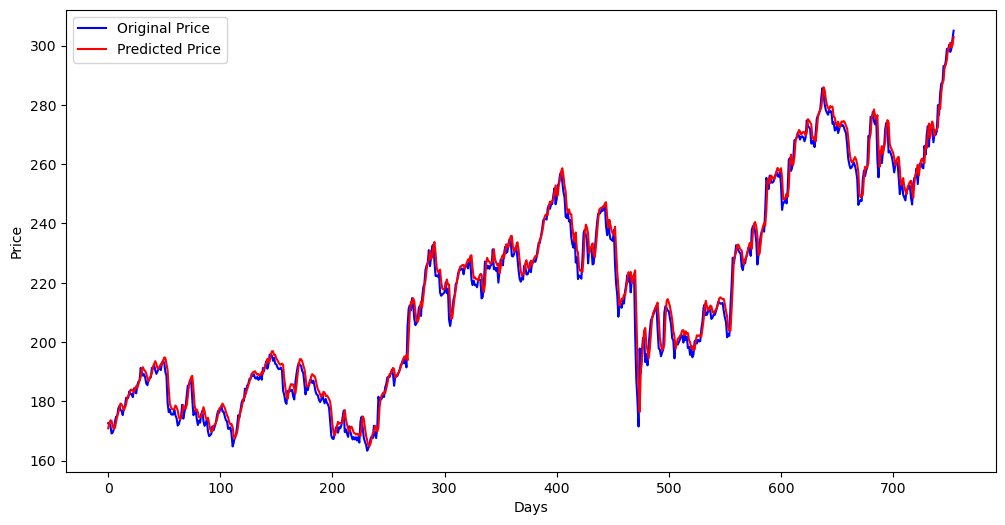

In [84]:
plt.figure(figsize = (12, 6))
plt.plot(y_test, 'b', label ='Original Price')
plt.plot(y_predicted, 'r', label ='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(150.0, 320.0)

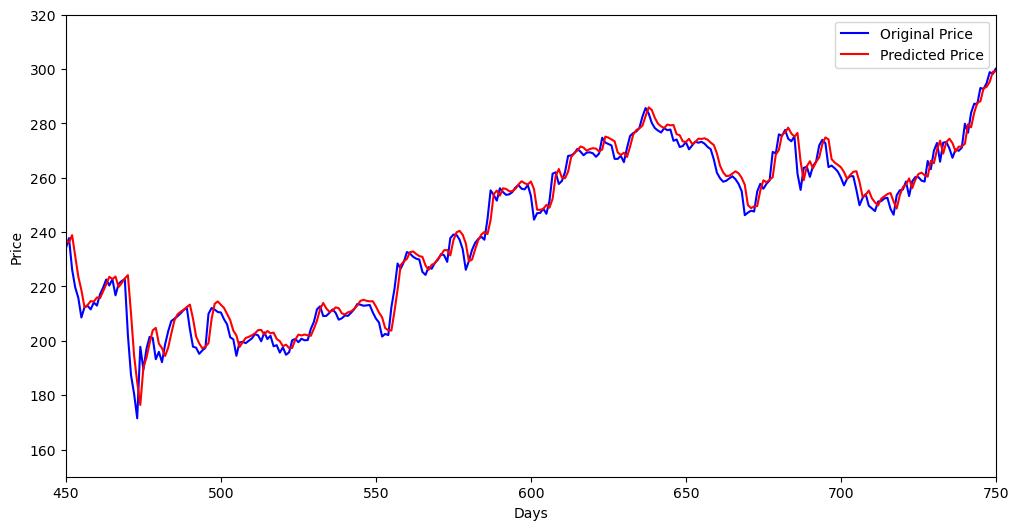

In [83]:
plt.figure(figsize = (12, 6))
plt.plot(y_test, 'b', label ='Original Price')
plt.plot(y_predicted, 'r', label ='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(150, 320)

# 10. Model Evaluation

In [90]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [86]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 15.148950500645064


In [87]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 3.8921652714967108


In [91]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9871172777785444
